# Gym Churn Analysis

Using gym churn data to explore different aspects of data analysis and predictive modeling.

The notebook works through the following steps:
- Exploratory data analysis - check data for missing values, plot churn rate by cat variables, plot numeric feature distributions by churn
- Statistical tests - check whether the means of numerical variables for churn vs not churn populations are statistically significant
- Cohort analysis - split data into cohorts based on length of gym membership. Show means of numeric variables by cohort, show contract period x cohort crosstab. Run t-tests to see if there is a significant enough difference in mean ages, and in avg class frequency by cohort.
- Clustering - Cluster within churners and non-churners separately to see what churner vs loyal segments look like 
- Predicting churn - train a random forest model to predict churn and plot feature importance
- Survival analysis for churn - build a survival forest model
- Analysis and recommendations

## TODO
- Clustering to find valuable segments
    - Cluster within churners or non-churners separately to see what churner vs loyal segments look like

- Statistical tests on clusters
- bootstrapping for churn prediction to create confidence intervals
- Extra data generation to balance classes and improve churn prediction performance 
- SHAP feature importance explanation

- Survival analysis
- Cohort analysis: Look at groups that joined around the same time and see how their churn patterns evolve.
    - run chi-square tests of indepencence for contingency tables

# Analysis

## Predicting Churn

When we train a churn prediction model, we use a measure called average precision, which tells us how good the model is at finding the actual churners among the people it flags as "high risk." By optimizing for this, we make sure the model is tuned to catch churners before they leave, while keeping wasted offers to loyal members as low as possible.

## Recommendations
- Data - other data points to collect: <TODO>

# Exploratory Data Analysis

## Data Columns
The dataset contains churn information for the current month and member data for the previous month.

- Churn - cancellation for the current month
- Gender - The user's gender
- Near_Location - If the user lives or works in the neighborhood where the gym is located.
- Partner - If the user works in an associated company (the gym has associated companies whose employees get discounts; in those cases, the gym stores information about the clients' employers).
- Promo_friends - If the user originally signed up through a "bring a friend" offer (they used a friend's promotional code when they paid the first subscription).
- Phone - If the user provided their phone number.
- Contract_period - The customer's contract period in months
- Group_visits - Whether the customer's membership allows to bring friends
- Age - The customer's age
- Avg_additional_charges_total
- Month_to_end_contract - Months until the contract ends
- Lifetime - the time (in months) since the user first arrived at the gym.
- Avg_class_frequency_total - Average number of classes the customer attended per week overall
- Avg_class_frequency_current_month - Average number of classes the customer attended per week in the current month

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from minieda import summarize # pip install git+https://github.com/dbolotov/minieda.git
from scipy.stats import ttest_ind, t

import time
from pprint import pprint

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import average_precision_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, f1_score
from sklearn.metrics import PrecisionRecallDisplay

from sklearn.inspection import permutation_importance


pd.set_option("display.precision", 2)


In [2]:
df = pd.read_csv("gym_churn_us.csv")

In [3]:
df

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.23,5.0,3,0.02,0.00,0
1,0,1,0,0,1,12,1,31,113.20,12.0,7,1.92,1.91,0
2,0,1,1,0,1,1,0,28,129.45,1.0,2,1.86,1.74,0
3,0,1,1,1,1,12,1,33,62.67,12.0,2,3.21,3.36,0
4,1,1,1,1,1,1,0,26,198.36,1.0,3,1.11,1.12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.41,12.0,8,2.28,2.35,0
3996,0,1,0,0,1,1,1,29,68.88,1.0,1,1.28,0.29,1
3997,1,1,1,1,1,12,0,28,78.25,11.0,2,2.79,2.83,0
3998,0,1,1,1,1,6,0,32,61.91,5.0,3,1.63,1.60,0


In [4]:
summarize(df)

,dtype,count,unique,unique_perc,missing,missing_perc,zero,zero_perc,mean,std,min,50%,max,skew
gender,int64,4000,2,0.05,0,0.0,1959,48.98,0.51,0.50,0.00,1.00,1.00,-0.04
Near_Location,int64,4000,2,0.05,0,0.0,619,15.48,0.85,0.36,0.00,1.00,1.00,-1.91
Partner,int64,4000,2,0.05,0,0.0,2053,51.32,0.49,0.50,0.00,0.00,1.00,0.05
Promo_friends,int64,4000,2,0.05,0,0.0,2766,69.15,0.31,0.46,0.00,0.00,1.00,0.83
Phone,int64,4000,2,0.05,0,0.0,386,9.65,0.90,0.30,0.00,1.00,1.00,-2.73
Contract_period,int64,4000,3,0.08,0,0.0,0,0.00,4.68,4.55,1.00,1.00,12.00,0.71
Group_visits,int64,4000,2,0.05,0,0.0,2351,58.78,0.41,0.49,0.00,0.00,1.00,0.36
Age,int64,4000,23,0.57,0,0.0,0,0.00,29.18,3.26,18.00,29.00,41.00,-0.06
Avg_additional_charges_total,float64,4000,4000,100.00,0,0.0,0,0.00,146.94,96.36,0.15,136.22,552.59,0.62
Month_to_end_contract,float64,4000,12,0.30,0,0.0,0,0.00,4.32,4.19,1.00,1.00,12.00,0.81


In [5]:
# Create lists of categorical and numerical variables
cat_vars = ["gender", "Near_Location", "Partner",  "Promo_friends", "Phone", "Contract_period", "Group_visits"]
num_vars = ["Age", "Avg_additional_charges_total", "Month_to_end_contract", "Lifetime", "Avg_class_frequency_total", "Avg_class_frequency_current_month"]

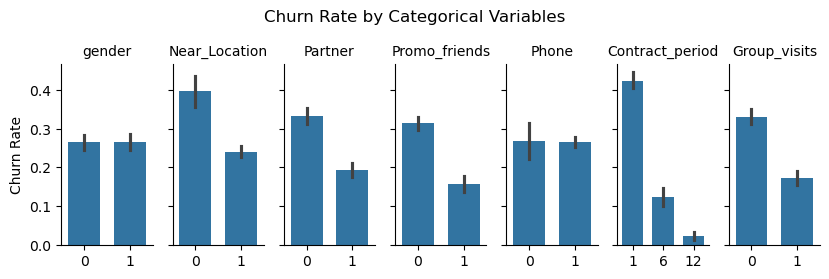

In [6]:
# Churn rate for categorical variables

g = sns.FacetGrid(
    pd.melt(df, id_vars="Churn", value_vars=cat_vars),
    col="variable", col_wrap=7, sharey=True, sharex=False, height=3, aspect=0.4)
g.map_dataframe(sns.barplot, x="value", y="Churn", estimator=lambda x: sum(x)/len(x), width=0.7)
g.set_axis_labels("", "Churn Rate")
g.set_titles("{col_name}")
g.fig.suptitle("Churn Rate by Categorical Variables")
g.fig.subplots_adjust(top=0.8)  # adjust to fit the title

plt.show()

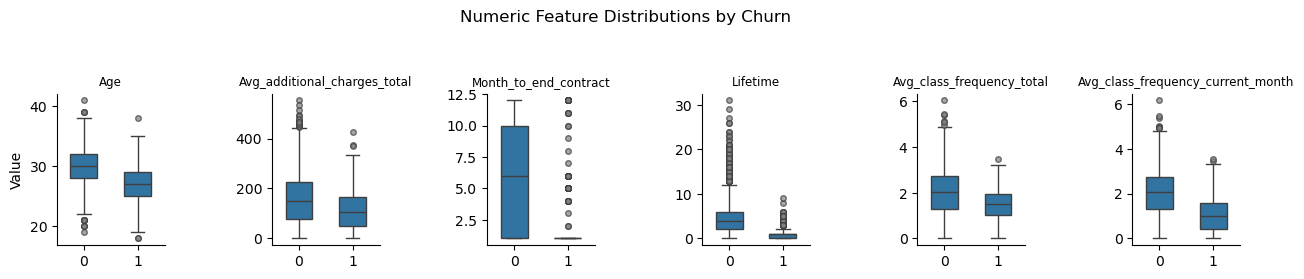

In [7]:
# Boxplots for numeric features by churn

df_plot = df.copy()

melted = pd.melt(df_plot, id_vars="Churn", value_vars=num_vars)

g = sns.FacetGrid(melted, col="variable", sharey=False, height=3, aspect=0.7)
g.map_dataframe(sns.boxplot, x="Churn", y="value", showfliers=True, 
                flierprops=dict(marker='o', markersize=4, markerfacecolor="gray", alpha=0.7),
                width=0.5)

g.set_titles("{col_name}", size=8.5)
g.set_axis_labels("", "Value")

g.fig.suptitle("Numeric Feature Distributions by Churn")
g.fig.subplots_adjust(top=0.7, wspace = 1)

plt.show()

In [8]:
# T-test 
# def run_ttest(variable):
#     churners = df[df["Churn"] == 1][variable]
#     non_churners = df[df["Churn"] == 0][variable]
#     t_stat, p_val = ttest_ind(churners, non_churners, equal_var=False)
#     print(f"{variable:<35} t-stat: {t_stat:>6.3f}   p-value: {p_val:.3e}")

def run_ttests(df, num_vars):
    results = []
    for var in num_vars:
        churners = df[df["Churn"] == 1][var]
        non_churners = df[df["Churn"] == 0][var]
        t_stat, p_val = ttest_ind(churners, non_churners, equal_var=False)
        results.append({"Variable": var, "t-stat": t_stat, "p-value": p_val})
    return(pd.DataFrame(results))

ttest_results = run_ttests(df, num_vars)
print(ttest_results)


                            Variable  t-stat    p-value
0                                Age  -28.50  1.44e-149
1       Avg_additional_charges_total  -14.39   4.23e-45
2              Month_to_end_contract  -36.00  1.28e-244
3                           Lifetime  -46.99   0.00e+00
4          Avg_class_frequency_total  -19.37   2.01e-78
5  Avg_class_frequency_current_month  -32.55  1.05e-193


In [9]:
import numpy as np
import pandas as pd


def run_ttests_with_means(df, num_vars, churn_col="Churn", pretty=False):
    """
    Compare numeric variables between churners (1) and non-churners (0).
    Uses Welch's t-test (unequal variances), and reports:
      - group means
      - mean difference (churners - non-churners)
      - t-statistic, p-value
      - 95% CI for the mean difference (Welch)
      - Hedges' g (effect size, small-sample corrected)

    Params
    ------
    df : DataFrame
    num_vars : list[str]
    churn_col : str (default "Churn")
    pretty : bool -> if True, returns a formatted table (strings)

    Returns
    -------
    DataFrame
    """
    rows = []

    for var in num_vars:
        g1 = df[df[churn_col] == 1][var].dropna()  # churners
        g0 = df[df[churn_col] == 0][var].dropna()  # non-churners

        n1, n0 = len(g1), len(g0)
        m1, m0 = g1.mean(), g0.mean()
        s1, s0 = g1.std(ddof=1), g0.std(ddof=1)

        # Welch t-test
        t_stat, p_val = ttest_ind(g1, g0, equal_var=False)

        # Mean difference and its SE (Welch)
        diff = m1 - m0
        se = np.sqrt((s1**2 / n1) + (s0**2 / n0))

        # Welch-Satterthwaite degrees of freedom
        df_welch_num = (s1**2 / n1 + s0**2 / n0) ** 2
        df_welch_den = ((s1**2 / n1) ** 2) / (n1 - 1) + ((s0**2 / n0) ** 2) / (n0 - 1)
        dof = df_welch_num / df_welch_den

        # 95% CI for mean difference
        t_crit = t.ppf(0.975, dof)
        ci_low = diff - t_crit * se
        ci_high = diff + t_crit * se

        # Effect size: Hedges' g (using pooled SD, then small-sample correction)
        sp2 = ((n1 - 1) * s1**2 + (n0 - 1) * s0**2) / (n1 + n0 - 2)
        sp = np.sqrt(sp2)
        d = diff / sp if sp > 0 else np.nan
        J = 1 - (3 / (4*(n1 + n0) - 9))  # small sample correction
        g_hedges = d * J

        rows.append({
            "Variable": var,
            "n_churn": n1, "mean_churn": m1,
            "n_non": n0, "mean_non": m0,
            "diff_mean": diff,
            "t_stat": t_stat, "p_value": p_val,
            "ci_low": ci_low, "ci_high": ci_high,
            "hedges_g": g_hedges
        })

    out = pd.DataFrame(rows).sort_values("p_value")

    if not pretty:
        return out.reset_index(drop=True)

    # Formatting
    out_fmt = out.copy()
    out_fmt["mean_churn"] = out_fmt["mean_churn"].map(lambda x: f"{x:.3f}")
    out_fmt["mean_non"]   = out_fmt["mean_non"].map(lambda x: f"{x:.3f}")
    out_fmt["diff_mean"]  = out_fmt["diff_mean"].map(lambda x: f"{x:+.3f}")
    out_fmt["t_stat"]     = out_fmt["t_stat"].map(lambda x: f"{x:.3f}")
    out_fmt["p_value"]    = out_fmt["p_value"].map(lambda x: f"{x:.3e}")
    out_fmt["ci"]         = out.apply(lambda r: f"[{r.ci_low:.3f}, {r.ci_high:.3f}]", axis=1)
    out_fmt["hedges_g"]   = out_fmt["hedges_g"].map(lambda x: f"{x:+.3f}")

    cols = ["Variable", "mean_churn", "mean_non",
            "diff_mean", "t_stat", "p_value", "ci", "hedges_g"]
    return out_fmt[cols].reset_index(drop=True)

results = run_ttests_with_means(df, num_vars, pretty=True)
results

,Variable,mean_churn,mean_non,diff_mean,t_stat,p_value,ci,hedges_g
0,Lifetime,0.991,4.712,-3.721,-46.990,0.000e+00,"[-3.876, -3.566]",-1.104
1,Month_to_end_contract,1.663,5.283,-3.621,-35.996,1.285e-244,"[-3.818, -3.423]",-0.934
2,Avg_class_frequency_current_month,1.045,2.028,-0.983,-32.553,1.049e-193,"[-1.043, -0.924]",-1.025
3,Age,26.990,29.977,-2.987,-28.501,1.438e-149,"[-3.192, -2.781]",-1.002
4,Avg_class_frequency_total,1.475,2.025,-0.550,-19.368,2.011e-78,"[-0.606, -0.494]",-0.584
5,Avg_additional_charges_total,115.083,158.446,-43.363,-14.391,4.230e-45,"[-49.271, -37.454]",-0.459


# Cohort analysis

Find groups of people that started around the same time and see how their churn patterns evolve.

Bin customers into 4 cohorts - New (<3 months), Early (3-5 months), Established (6-11 months), Loyal (12+ months).

In [10]:
df

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.23,5.0,3,0.02,0.00,0
1,0,1,0,0,1,12,1,31,113.20,12.0,7,1.92,1.91,0
2,0,1,1,0,1,1,0,28,129.45,1.0,2,1.86,1.74,0
3,0,1,1,1,1,12,1,33,62.67,12.0,2,3.21,3.36,0
4,1,1,1,1,1,1,0,26,198.36,1.0,3,1.11,1.12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.41,12.0,8,2.28,2.35,0
3996,0,1,0,0,1,1,1,29,68.88,1.0,1,1.28,0.29,1
3997,1,1,1,1,1,12,0,28,78.25,11.0,2,2.79,2.83,0
3998,0,1,1,1,1,6,0,32,61.91,5.0,3,1.63,1.60,0


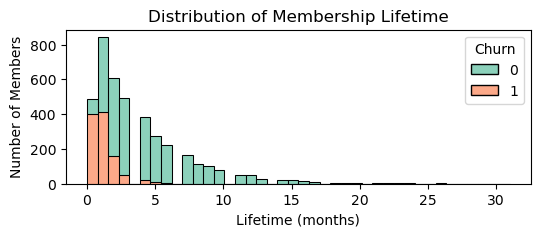

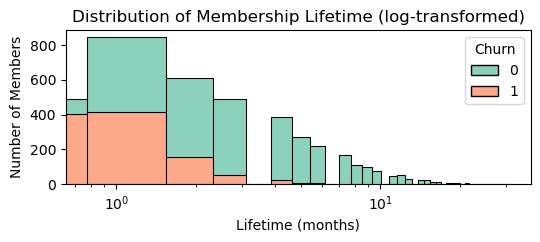

In [11]:
# Show distribution of Lifetime and separate by Churn
plt.figure(figsize=(6,2))

sns.histplot(data=df, x="Lifetime", bins=40, kde=False, hue="Churn", multiple="stack", palette="Set2")

plt.title("Distribution of Membership Lifetime")
plt.xlabel("Lifetime (months)")
plt.ylabel("Number of Members")
plt.show()

plt.figure(figsize=(6,2))
sns.histplot(data=df, x="Lifetime", bins=40, kde=False, hue="Churn", multiple="stack", palette="Set2")
plt.xscale("log")
plt.title("Distribution of Membership Lifetime (log-transformed)")
plt.xlabel("Lifetime (months)")
plt.ylabel("Number of Members")
plt.show()

In [12]:
# Separate data into cohorts based on Lifetime:

df_cohort = df.copy(deep=True)

df_cohort["Cohort"] = pd.cut(x=df_cohort["Lifetime"], bins=[0, 3, 6, 12, np.inf], right=False,
                             labels=["New", "Early", "Established", "Loyal"], retbins=False,
                             precision=3, include_lowest=True, duplicates='raise', ordered=True)

In [13]:
df_cohort

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn,Cohort
0,1,1,1,1,0,6,1,29,14.23,5.0,3,0.02,0.00,0,Early
1,0,1,0,0,1,12,1,31,113.20,12.0,7,1.92,1.91,0,Established
2,0,1,1,0,1,1,0,28,129.45,1.0,2,1.86,1.74,0,New
3,0,1,1,1,1,12,1,33,62.67,12.0,2,3.21,3.36,0,New
4,1,1,1,1,1,1,0,26,198.36,1.0,3,1.11,1.12,0,Early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.41,12.0,8,2.28,2.35,0,Established
3996,0,1,0,0,1,1,1,29,68.88,1.0,1,1.28,0.29,1,New
3997,1,1,1,1,1,12,0,28,78.25,11.0,2,2.79,2.83,0,New
3998,0,1,1,1,1,6,0,32,61.91,5.0,3,1.63,1.60,0,Early


In [14]:
# Create summary with member counts, and means of numerical variables by cohort
df_c_summary = (df_cohort.groupby("Cohort", observed=False)
                .agg(Member_Count=("Churn", "size"),
                     Member_Perc=("Churn", lambda x: len(x) / len(df_cohort)),
                     Churn_Perc=("Churn", "mean"),
                     Age_mean=("Age", "mean"),
                     Avg_addl_charges_tot_mean =("Avg_additional_charges_total", "mean"),
                     Avg_class_f_tot_mean=("Avg_class_frequency_total", "mean"),
                     Avg_class_f_cm_mean=("Avg_class_frequency_current_month", "mean")))

df_c_summary["Member_Perc"] = (df_c_summary["Member_Perc"] * 100)
df_c_summary["Churn_Perc"]  = (df_c_summary["Churn_Perc"] * 100)

df_c_summary

,Member_Count,Member_Perc,Churn_Perc,Age_mean,Avg_addl_charges_tot_mean,Avg_class_f_tot_mean,Avg_class_f_cm_mean
Cohort,,,,,,,
New,1940,48.50,50.21,28.47,137.53,1.73,1.52
Early,1146,28.65,7.07,29.79,156.29,2.01,1.98
Established,722,18.05,0.83,30.00,153.78,2.03,2.02
Loyal,192,4.80,0.00,29.68,160.56,2.01,2.02


Average class frequency total - Churners tend to leave early, and those who stay quickly settle into a routine of about 2 visits per week. Past 6 months, engagement stabilizes, suggesting that keeping members engaged through the first 3 months is critical.

Age - mean age is around 28-30 years old - not a large gap.


In [15]:
# Show contingency table of Cohort and Contract_period
pd.crosstab(df_cohort["Cohort"], df_cohort["Contract_period"], normalize="index").map(lambda x: f"{x:.0%}") #normalized so each cohort (row) sums to 1.

Contract_period,1,6,12
Cohort,,,
New,65%,18%,17%
Early,46%,24%,29%
Established,44%,23%,33%
Loyal,48%,22%,30%


The above table shows that among new members, 65% are on a 1-month contract. Among Loyal members (12+ months attendance), almost half (48%) are on 1-month contract. If monthly cost difference between 1- and 12-month contracts is small, members might not bother to switch. A potential action here is to target loyal month-to-month members with offers to switch to a discounted 12-month plan. Even if churn is already low, locking them in creates more predictable revenue.

# Predicting churn with a machine learning model
Train and evaluate a Random Forest model to predict whether a customer churns in the current month given data for the past month.


In the **Model Training** section, we pre-process the data by scaling numeric variables and one-hot encoding categorical variables, and then run a grid search to find the best parameters for a random forest model, optimizing for average precision.

In the **Model Evaluation** section, we report the PR-AUC and ROC-AUC, plot Precision-Recall curve, and find the threshold at which 80% of churners will be correctly detected by the model. We also explore setting up churn risk tiers based on predicted churn probability, which can be used for targeted retention offers. Finally, we show how to score a new observation with this model.

**Why use average precision during grid search?**
- Optimizing average precision finds parameters which will work with different thresholds. We can then change the decision threshold to tailor the model to specific business use cases. Optimizing a specific metric (like F1 score or Recall) trains the model for that specific metric only.

In [16]:
# Print value counts (normalized and raw)
print(df['Churn'].value_counts(normalize=True))
print(df['Churn'].value_counts(normalize=False))

Churn
0    0.73
1    0.27
Name: proportion, dtype: float64
Churn
0    2939
1    1061
Name: count, dtype: int64


The data is imbalanced - only 27% of observations represent customers that churned.

In [17]:
# Split the data
X = df[cat_vars + num_vars]
y = df['Churn']

# Split into training and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define preprocessing for numeric and categorical features
numeric_preprocessing = Pipeline([
    ('scale', StandardScaler())
])

categorical_preprocessing = Pipeline([
    ('encode', OneHotEncoder(drop='first', sparse_output=False))  # one-hot; drop first feature to avoid multicollinearity
])

# Combine into a column transformer
preprocessor = ColumnTransformer([
    ('num', numeric_preprocessing, num_vars),
    ('cat', categorical_preprocessing, cat_vars)
])

In [18]:
# Grid search

# Base pipeline
clf_pipeline = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# Define hyperparameter grid
param_grid = {
    'model__n_estimators': [40,100,200],
    'model__max_depth': [None],
    'model__min_samples_leaf': [1, 3, 5, 7],
    'model__max_features': ['sqrt']
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=clf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='average_precision',
    n_jobs=-1,
    verbose=2
)

# Fit grid search on training data
print("Running Grid Search...")
start_time = time.time()
grid_search.fit(X_train, y_train)
print(f"\nGrid search completed in {time.time() - start_time:.2f} seconds")

Running Grid Search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Grid search completed in 8.97 seconds


In [19]:
print("Best Grid Search Result:\n")
print(f"Average Precision: {grid_search.best_score_:.4f} ± {grid_search.cv_results_['std_test_score'][grid_search.best_index_]:.4f}")
print("Parameters:")
pprint(grid_search.best_params_)

Best Grid Search Result:

Average Precision: 0.9248 ± 0.0078
Parameters:
{'model__max_depth': None,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 3,
 'model__n_estimators': 100}


## Model evaluation
In this section, we evaluate how well the churn model works on the test set, and how its results can be used in practice.

- **Report overall scores**: We calculate PR-AUC and ROC-AUC on the test set. These metrics summarize model quality without fixing a threshold. PR-AUC is compared to the baseline churn rate, while ROC-AUC is compared to 0.5 (random guessing).

- **Plot the Precision–Recall curve**: The curve shows how recall (detecting churners) and precision (how many flagged members really churn) trade off at different probability cutoffs.

- **Detect 80% of all churners**: We set a business rule that the model should catch at least 80% of members about to churn. Using the PR curve, we find the probability threshold that meets this requirement. At this cutoff, we calculate the confusion matrix and report precision and recall. To make trade-offs clear, we also show statistics for a few other detection percentages.

- **Define risk tiers**: Instead of one cutoff, we also group members into risk bands based on churn probability. For each tier we report the number of member, their average predicted churn probability, and the actual churn rate in the test set. This makes it easier to decide which groups get which retention actions (for example, discounts for high risk, emails for medium risk, no action for low risk).

- **Explore feature importance**: <TODO>

- **Score new members**: Finally, we show how to apply the model to a new observation: get the churn probability, map it into the right risk tier, and interpret it in the business context.

### Overall score for best model

The best model reaches a PR-AUC of 0.93, compared to a baseline of 0.27 (the churn rate in the test set). This means the model is much better than random guessing at ranking members by churn risk.

It also achieves a ROC-AUC of 0.97 (baseline = 0.50), showing it can reliably separate churners from non-churners overall.

Because churn is relatively rare (about 27% of members), PR-AUC is the more meaningful measure. It shows how well the model balances catching churners (recall) with avoiding false alarms (precision) across all possible decision thresholds.

In [20]:
# Use best model from grid search
clf_pipeline = grid_search.best_estimator_

# Get probabilities for Churn = 1
y_test_pred_proba = clf_pipeline.predict_proba(X_test)[:, 1]

print(f"Model PR-AUC: {average_precision_score(y_test, y_test_pred_proba):.3f} (baseline = {y_test.mean():.3f})")
print(f"Model ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba):.3f} (baseline = 0.500)")

Model PR-AUC: 0.930 (baseline = 0.265)
Model ROC-AUC: 0.967 (baseline = 0.500)


### Plotting Precision-Recall curve

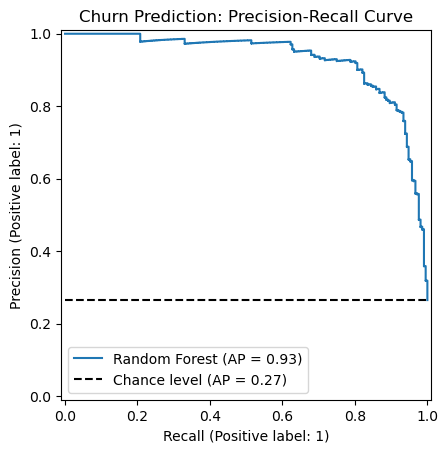

In [21]:
# Plot PR curve
display = PrecisionRecallDisplay.from_estimator(clf_pipeline, X_test, y_test, name="Random Forest",
                                                plot_chance_level=True, despine=False)
_ = display.ax_.set_title("Churn Prediction: Precision-Recall Curve")


### Detecting 80% of all churners

Let's say that we have a business need where we want to detect at least 80% of all churners. We can use the PR curve to find a **decision threshold** that corresponds to this percentage. This threshold is then used by the model to decide whether the churn probability predicted for an observation is labeled as churn (1) or not-churn (0). Specifically, when probability>=threshold, set Churn=1. We then use this threshold to get the churn prediction for all data in the test set, and calculate the confusion matrix and other metrics.

#### Interpreting results
We see the following after applying the 80% rule:
- The model threshold for predicting churn=1 is 0.519. This is slightly above the default value of 0.5.
- Recall = 170 / (170 + 42) = 80.2% (we’re detecting about 4 out of 5 churners).
- Precision = 170 / (170 + 14) = 92.4% (most flags are real churners).
- Members flagged = 184 (170 TP + 14 FP), which is 31% of the test set.

### Exploring the confusion matrix at different decision thresholds

- In this section we test how the model behaves when we change the cutoff used to turn churn probabilities into yes/no predictions.
- A higher threshold means the model is stricter: fewer members are flagged, precision goes up, but more churners are missed (higher false negatives).
- A lower threshold means the model is more lenient: more members are flagged, recall goes up, but many of them will be false alarms (higher false positives).
- The table below shows precision, recall, confusion-matrix counts, and the share of members flagged at several decision thresholds chosen to meet different detection targets (20%, 50%, 80%, 100% of churners detected).

#### Interpreting the results

- At the 80% target, the model catches about 4 out of 5 churners (recall = 80.2%) while still maintaining strong precision (92.4%). Roughly 23% of all members would be flagged for follow-up.
- At the 50% target, fewer churners are caught (half), but precision is nearly perfect (98%). This means that nearly all customers flagged are indeed going to churn.
- Pushing recall to 100% guarantees we don’t miss any churners, but it requires flagging 83% of the entire member base, which would be impractical in a real retention campaign.
- The business trade-off is that higher recall results in more churners saved, but also more members unnecessarily flagged.
- Takeaway: 80% recall looks like the sweet spot, with a high coverage of churners without overwhelming false alarms.

In [22]:
# Define recall levels to target (detection targets)
recall_targets = [0.2, 0.5, 0.8, 1.0]

# Get precision-recall-threshold curve
prec_curve, rec_curve, thr_curve = precision_recall_curve(y_test, y_test_pred_proba)

rows = []
n = len(y_test)

for r_target in recall_targets:
    # Find the highest threshold that still gives recall >= r_target
    idx = np.where(rec_curve >= r_target)[0][-1]
    thr = thr_curve[idx] if idx < len(thr_curve) else 0.0
    
    # Predictions at this threshold
    y_pred_thr = (y_test_pred_proba >= thr).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    prec = precision_score(y_test, y_pred_thr, zero_division=0)
    rec  = recall_score(y_test, y_pred_thr, zero_division=0)
    f1   = f1_score(y_test, y_pred_thr, zero_division=0)
    flagged = tp + fp
    
    rows.append({
        "Detection Target (% churners)": f"{int(r_target*100)}%",
        "Decision Threshold": f"{thr:.3f}",
        "Precision (% of flagged who churn)": f"{prec*100:.1f}%",
        "Recall (% of churners detected)": f"{rec*100:.1f}%",
        # "F1": f"{f1:.3f}",
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "% of all members flagged": f"{flagged/n*100:.1f}%"
    })

df_threshold_summary = pd.DataFrame(rows)
df_threshold_summary

,Detection Target (% churners),Decision Threshold,Precision (% of flagged who churn),Recall (% of churners detected),TP,FP,FN,TN,% of all members flagged
0,20%,0.926,100.0%,20.3%,43,0,169,588,5.4%
1,50%,0.800,98.1%,50.0%,106,2,106,586,13.5%
2,80%,0.519,92.4%,80.2%,170,14,42,574,23.0%
3,100%,0.009,31.9%,100.0%,212,453,0,135,83.1%


## Churn Risk Tiers

Instead of using a single cutoff, we group members into four risk tiers based on their predicted churn probability. Each tier shows how many members fall into it, what percentage of the test set that represents, the model’s average predicted churn rate for the tier, and the actual observed churn rate in the test data. This makes it easier to plan retention actions at different levels of risk rather than treating churn as a simple yes/no decision.

### Interpreting the results

- The Very High risk tier (≥70% probability of churning) contains 17.6% of members, and almost all of them churned (95%).
- The High risk tier (50–70%) is smaller (6.1% of members) but still has a very high observed churn rate of 75.5%.
- The Medium tier (30–50%) shows roughly 42% churn, while the Low tier (<30%) has only 3% churn.

This separation shows that the model is useful for targeting: the higher the predicted risk, the more likely members are to churn in reality. One notable pattern is that in the medium, high, and very high tiers, the observed churn rate is higher than the model’s predicted average. This means the model is somewhat conservative in its probability estimates, and underestimates how risky these groups truly are.

In [27]:
# Build a  DataFrame for the test set
test_df = pd.DataFrame({"actual": y_test.reset_index(drop=True),
                        "p_churn": y_test_pred_proba})

# Define fixed-probability tiers
labels = ["Low (<30%)", "Medium (30%–50%)", "High (50%–70%)", "Very High (≥70%)"]
test_df["risk_tier"] = pd.cut(test_df["p_churn"],
                              bins=[0.0, 0.30, 0.50, 0.70, 1.01],
                              labels=labels,
                              right=False, include_lowest=True)
test_df["risk_tier"] = test_df["risk_tier"].astype(pd.CategoricalDtype(categories=labels, ordered=True))

# Summarize by tier
n = len(test_df)
tier_summary = (test_df.groupby("risk_tier", observed=False)
                .agg(members=("actual", "size"),
                     pred_churn_rate=("p_churn", "mean"),
                     obs_churn_rate=("actual", "mean"))
                    .assign(members_pct=lambda d: d["members"] / n)
                    .reset_index())

# Order columns and format for business readability
tier_summary = tier_summary[["risk_tier", "members", "members_pct", "pred_churn_rate", "obs_churn_rate"]]
tier_summary.columns = ["Churn Risk Tier", "Members", "% of Members", "Avg Predicted Churn Rate", "Avg Observed Churn Rate"]

# Numeric copy (if you want raw numbers for further math)
tier_summary_numeric = tier_summary.copy()

# Display-friendly formatting
tier_summary_table = tier_summary.copy()
tier_summary_table["% of Members"]       = (tier_summary_table["% of Members"] * 100).map(lambda x: f"{x:.1f}%")
tier_summary_table["Avg Predicted Churn Rate"] = (tier_summary_table["Avg Predicted Churn Rate"] * 100).map(lambda x: f"{x:.1f}%")
tier_summary_table["Avg Observed Churn Rate"]  = (tier_summary_table["Avg Observed Churn Rate"] * 100).map(lambda x: f"{x:.1f}%")

tier_summary_table

,Churn Risk Tier,Members,% of Members,Avg Predicted Churn Rate,Avg Observed Churn Rate
0,Low (<30%),553,69.1%,6.1%,3.1%
1,Medium (30%–50%),57,7.1%,40.1%,42.1%
2,High (50%–70%),49,6.1%,60.6%,75.5%
3,Very High (≥70%),141,17.6%,86.7%,95.0%


## Feature Importance

To understand what drives churn predictions, we look at feature importance. This tells us which inputs the model relies on most when making decisions. We use two complementary approaches:

- **Random Forest built-in importance**: looks at how often and how strongly a feature is used to split the data inside the trees.

- **Permutation importance**: tests the trained model by shuffling each feature and seeing how much performance drops. This is often more reliable, because it measures impact on actual predictions, not just tree mechanics.

Both methods give a ranking of features, helping us see which factors matter most.


### Interpreting the results

Across both approaches, the top drivers of churn are consistent: Lifetime, recent class frequency and overall class frequency, age, and month to end contract.

Other features such as referral promotions, group visits, or demographics (gender, location, phone flag) add little value.

Takeaway: engagement behaviors (attendance) and tenure/contract features dominate the model, while demographics do not. This means retention actions should focus on usage and membership design, not personal characteristics.

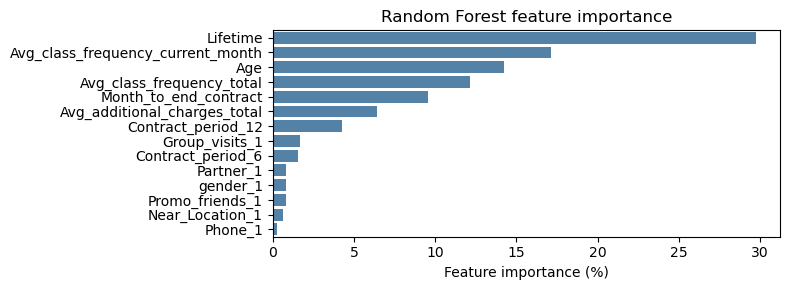

In [50]:
# Plot feature importance
model = clf_pipeline.named_steps["model"]
feature_names = clf_pipeline.named_steps["pre"].get_feature_names_out()

# Clean feature names for readability
clean_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

fi = (pd.DataFrame({"feature": clean_names, "importance": model.feature_importances_})
      .sort_values("importance", ascending=False))

# Normalize to percent, add cumulative %
fi["importance_pct"] = 100 * fi["importance"] / fi["importance"].sum()
fi["cum_%"] = fi["importance_pct"].cumsum()

plt.figure(figsize=(8, 3))
sns.barplot(data=fi, y="feature", x="importance_pct", color="steelblue")
plt.xlabel("Feature importance (%)")
plt.ylabel("")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()

# print(fi)

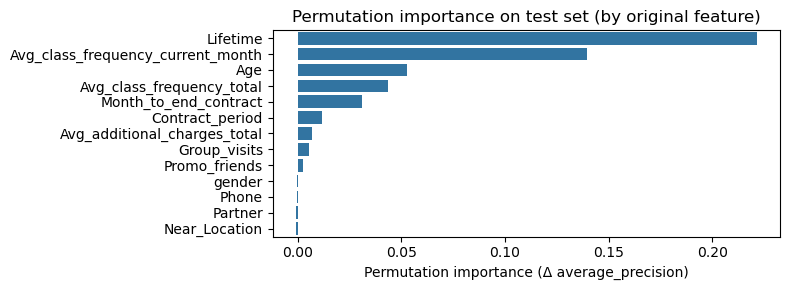

In [49]:
# Permutation importance on the full pipeline and original inputs
r = permutation_importance(
    clf_pipeline, X_test, y_test,
    scoring="average_precision",
    n_repeats=10, random_state=42, n_jobs=-1
)

#Use original column names (one per input feature)
orig_feature_names = list(X_test.columns)

pi = (pd.DataFrame({
        "feature": orig_feature_names,
        "mean_importance": r.importances_mean,
        "std": r.importances_std
     }).sort_values("mean_importance", ascending=False))

# Plot features
plt.figure(figsize=(8,3))
sns.barplot(data=pi, y="feature", x="mean_importance")
plt.xlabel("Permutation importance (Δ average_precision)")
plt.ylabel("")
plt.title("Permutation importance on test set (by original feature)")
plt.tight_layout()
plt.show()

# print(pi)

# Additional Plots

In [ ]:
# Get predicted probabilities for churn = 1
y_test_pred_proba = clf_pipeline.predict_proba(X_test)[:, 1]

# Build a DataFrame for plotting
proba_df = pd.DataFrame({
    "Churn_Prob": y_test_pred_proba,
    "Actual": y_test.reset_index(drop=True)  # ensure alignment
})

plt.figure(figsize=(8,4))
sns.histplot(
    data=proba_df, x="Churn_Prob", hue="Actual",
    bins=30, kde=False, stat="density", common_norm=False,
    palette={0:"steelblue", 1:"orange"}
)

# Add threshold lines with their own labels
plt.axvline(0.5, color="black", linestyle="--", label="Threshold = 0.5")
# Example: add business rule threshold at 0.35
plt.axvline(0.35, color="red", linestyle="--", label="Business threshold = 0.35")

plt.xlabel("Predicted Probability of Churn")
plt.ylabel("Density")
plt.title("Distribution of Predicted Churn Probabilities")
plt.legend(title="Legend")
plt.show()

In [26]:
# Calculate model prediction bias